# Notebook 1: Data Exploration and Preprocessing 🔍

## 🎯 Objective 1 & 2 
In this notebook, we will:
1. Define the multi-class classification problem (38 classes).
2. Load and explore the PlantVillage dataset to analyze class balances.
3. Apply data preprocessing (resizing, scaling, normalization) and augmentation (rotation, flipping). 
4. Split the data into Train, Validation, and Test sets and create PyTorch DataLoaders. 

In [1]:
# Import necessary libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torchvision

# Set up device configuration (Use GPU if available, otherwise fallback to CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Dataset Exploration
Our dataset contains 38 different combinations of plants and diseases. We will specifically use the `color` images folder because Convolutional Neural Networks (CNNs) perform best when they have rich color data to find patterns (like yellowing leaves or dark spots).

In [2]:
# Set the correct path to the color images based on our folder structure
dataset_path = "../dataset/plantvillage-dataset/color"

# Dictionary to hold the count of images per class
class_counts = {}

# Loop through every folder (class) in the dataset directory
for plant_class in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, plant_class)

    # Ensure we are only looking at directories
    if os.path.isdir(class_path):
        # Count the files inside the directory
        num_images = len(os.listdir(class_path))
        class_counts[plant_class] = num_images

# Convert our dictionary to a Pandas DataFrame to easily sort and view it
df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Image Count"])
df = df.sort_values(by="Image Count", ascending=False)

# Display the findings
print(f"Total Images in Dataset: {df['Image Count'].sum()}")
print(f"Total Number of Classes: {len(df)}")
print("\n--- Top 5 Classes (Most Images) ---")
print(df.head())
print("\n--- Bottom 5 Classes (Fewest Images) ---")
print(df.tail())

Total Images in Dataset: 54305
Total Number of Classes: 38

--- Top 5 Classes (Most Images) ---
                                       Class  Image Count
15  Orange___Haunglongbing_(Citrus_greening)         5507
37    Tomato___Tomato_Yellow_Leaf_Curl_Virus         5357
24                         Soybean___healthy         5090
16                    Peach___Bacterial_spot         2297
28                   Tomato___Bacterial_spot         2127

--- Bottom 5 Classes (Fewest Images) ---
                           Class  Image Count
36  Tomato___Tomato_mosaic_virus          373
23           Raspberry___healthy          371
17               Peach___healthy          360
2       Apple___Cedar_apple_rust          275
21              Potato___healthy          152


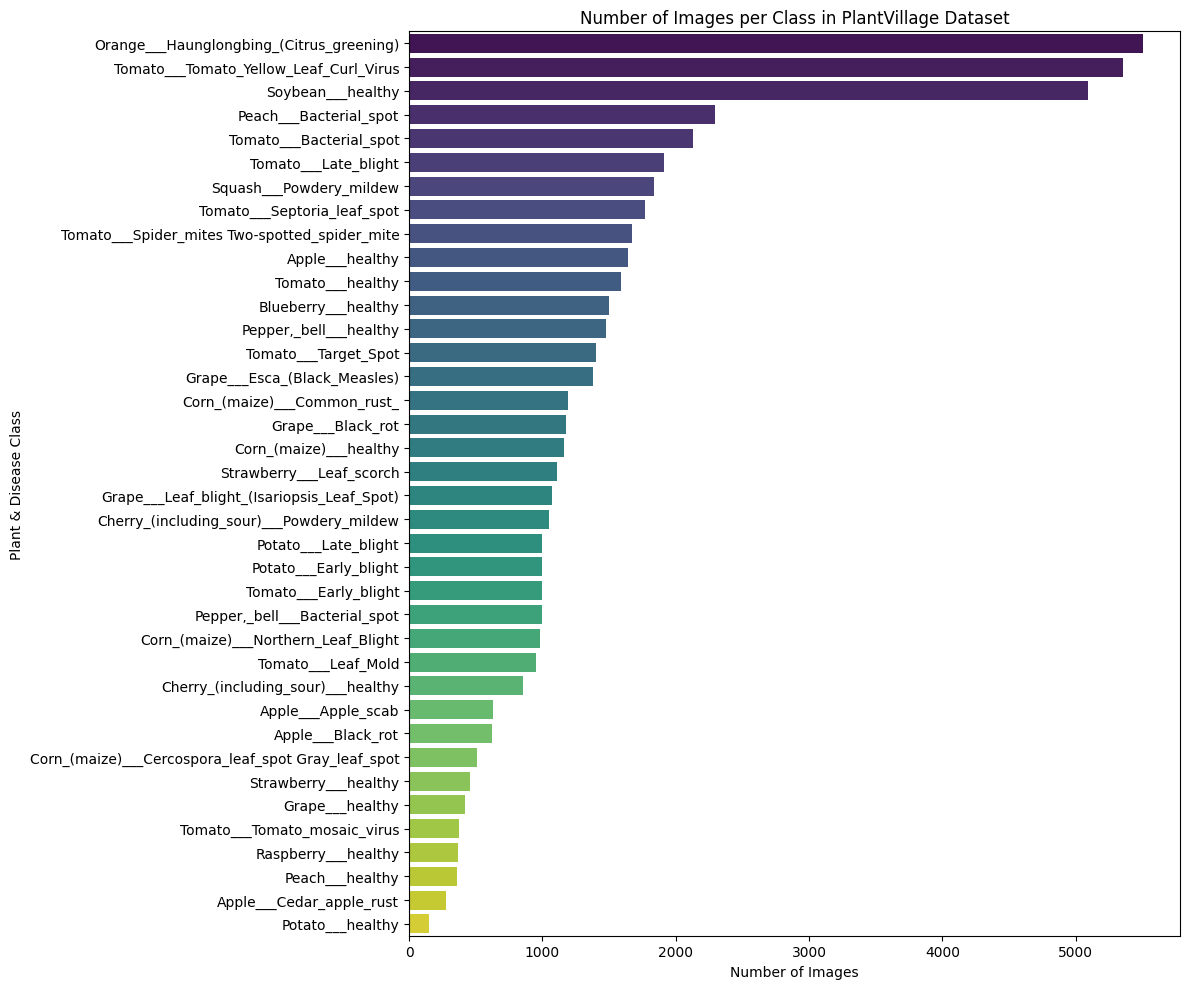

In [3]:
# Visualize the class distribution to check for imbalance
plt.figure(figsize=(12, 10))
sns.barplot(
    x="Image Count", y="Class", data=df, hue="Class", palette="viridis", legend=False
)
plt.title("Number of Images per Class in PlantVillage Dataset")
plt.xlabel("Number of Images")
plt.ylabel("Plant & Disease Class")
plt.tight_layout()
plt.show()

## 2. Data Preprocessing & Augmentation
Neural networks require standardized inputs. We will:
* **Resize** all images to 224x224 pixels (the standard size for most deep learning models like ResNet).
* **Normalize** the images using ImageNet standard mean and standard deviation.
* Apply **Data Augmentation** to the training set (random flips and rotations) to prevent overfitting by artificially increasing our dataset variety.

In [ ]:
# Define transformations for the Training set (includes augmentation)
train_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),  # Flip images left-to-right randomly
        transforms.RandomRotation(15),  # Rotate images by up to 15 degrees
        transforms.ToTensor(),  # Convert image to PyTorch Tensor (scales pixels 0 to 1)
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        ),  # Standard ImageNet normalization
    ]
)

# Define transformations for Validation/Test sets (NO augmentation, just resize and normalize)
test_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

print("Transforms defined successfully.")

Transforms defined successfully.


## 3. Dataset Splitting and DataLoaders
We will use PyTorch's `ImageFolder` to load our dataset. Then, we will split our data into:
* **80% Training:** To teach the model.
* **10% Validation:** To evaluate the model during training and tune hyperparameters.
* **10% Testing:** To do a final evaluation on completely unseen data.

In [ ]:
import copy

# Load the dataset using ImageFolder (it automatically assigns labels based on folder names)
full_dataset = datasets.ImageFolder(root=dataset_path, transform=train_transforms)

# Calculate the sizes for our 80/10/10 split
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

# Perform the random split
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42),  # Seed for reproducibility
)

# Deepcopy the datasets so we don't overwrite the training augmentations
val_dataset.dataset = copy.deepcopy(full_dataset)
val_dataset.dataset.transform = test_transforms

test_dataset.dataset = copy.deepcopy(full_dataset)
test_dataset.dataset.transform = test_transforms

# Create DataLoaders to load data in batches
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Save the class names mapping for later use in our Flask app
class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Number of classes detected: {num_classes}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

print("DataLoaders are ready!")

Number of classes detected: 38
Training batches: 1358
Validation batches: 170


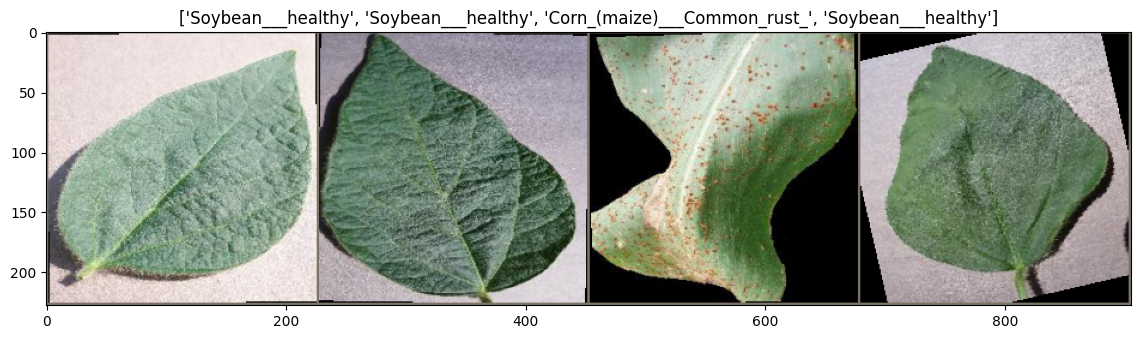

In [ ]:
import numpy as np


# Let's verify our pipeline by visualizing a single batch of training images
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    # Un-normalize the image so we can view it properly
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)


# Get a batch of training data
inputs, classes = next(iter(train_loader))

# Extract the first 4 images to display
out = torchvision.utils.make_grid(inputs[:4])

# Display the images with their folder names as titles
plt.figure(figsize=(14, 5))
imshow(out, title=[class_names[x] for x in classes[:4]])

## ⏭️ Next Steps
Data preprocessing is complete! We have successfully:
* Analyzed the class distribution.
* Set up standard transformations and image augmentations.
* Created structured DataLoaders for PyTorch.

**Next in Notebook 2:** We will design a Custom CNN architecture from scratch and train it using the `train_loader` we just built.